<a href="https://colab.research.google.com/github/Nammu48/Cattle-breed-identification/blob/main/CattleVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

New method

In [ ]:
!pip install timm -q

import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/Cattle Vision Dataset/train"
val_dir   = "/content/drive/MyDrive/Cattle Vision Dataset/validation"
test_dir  = "/content/drive/MyDrive/Cattle Vision Dataset/test"

Mounted at /content/drive


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {num_classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 41
Train: 4014 | Val: 730 | Test: 1193


In [ ]:
def build_model(model_name, num_classes):
    """
    model_name options: 'resnet50', 'efficientnet_b0', 'vit_base_patch16_224'
    """
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model.to(device)

MODEL_CONFIGS = {
    "resnet50": "resnet50",
    "efficientnet_b0": "efficientnet_b0",
    "vit": "vit_base_patch16_224",
}

In [ ]:
def train_model(model, model_name, train_loader, val_loader, num_epochs=15, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        start = time.time()

        # ---- Train ----
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)

        train_loss = running_loss / total
        train_acc = running_corrects.double() / total

        # ---- Validate ----
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)

        val_loss = val_loss / val_total
        val_acc = val_corrects.double() / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc.item())

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} "
              f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} "
              f"| Time: {time.time()-start:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    print(f"Best Val Acc for {model_name}: {best_val_acc:.4f}")
    return model, history

In [ ]:
def evaluate_model(model, test_loader, class_names, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\n===== {model_name} Test Report =====")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Overall Test Accuracy: {acc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return acc


Training resnet50


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

[resnet50] Epoch 1/15 | Train Loss: 3.5645 Acc: 0.0899 | Val Loss: 3.3832 Acc: 0.1233 | Time: 785.4s
[resnet50] Epoch 2/15 | Train Loss: 3.1666 Acc: 0.1609 | Val Loss: 2.9324 Acc: 0.2452 | Time: 48.8s
[resnet50] Epoch 3/15 | Train Loss: 2.7387 Acc: 0.2843 | Val Loss: 2.4957 Acc: 0.3233 | Time: 46.9s
[resnet50] Epoch 4/15 | Train Loss: 2.3741 Acc: 0.3440 | Val Loss: 2.1967 Acc: 0.3836 | Time: 47.5s
[resnet50] Epoch 5/15 | Train Loss: 2.1031 Acc: 0.3999 | Val Loss: 1.9981 Acc: 0.4247 | Time: 47.4s
[resnet50] Epoch 6/15 | Train Loss: 1.9105 Acc: 0.4482 | Val Loss: 1.8591 Acc: 0.4548 | Time: 47.2s
[resnet50] Epoch 7/15 | Train Loss: 1.7534 Acc: 0.4930 | Val Loss: 1.7741 Acc: 0.4658 | Time: 49.1s
[resnet50] Epoch 8/15 | Train Loss: 1.6435 Acc: 0.5120 | Val Loss: 1.7083 Acc: 0.4918 | Time: 47.8s
[resnet50] Epoch 9/15 | Train Loss: 1.5661 Acc: 0.5411 | Val Loss: 1.6647 Acc: 0.5137 | Time: 47.5s
[resnet50] Epoch 10/15 | Train Loss: 1.4972 Acc: 0.5613 | Val Loss: 1.6438 Acc: 0.5192 | Time: 47.1

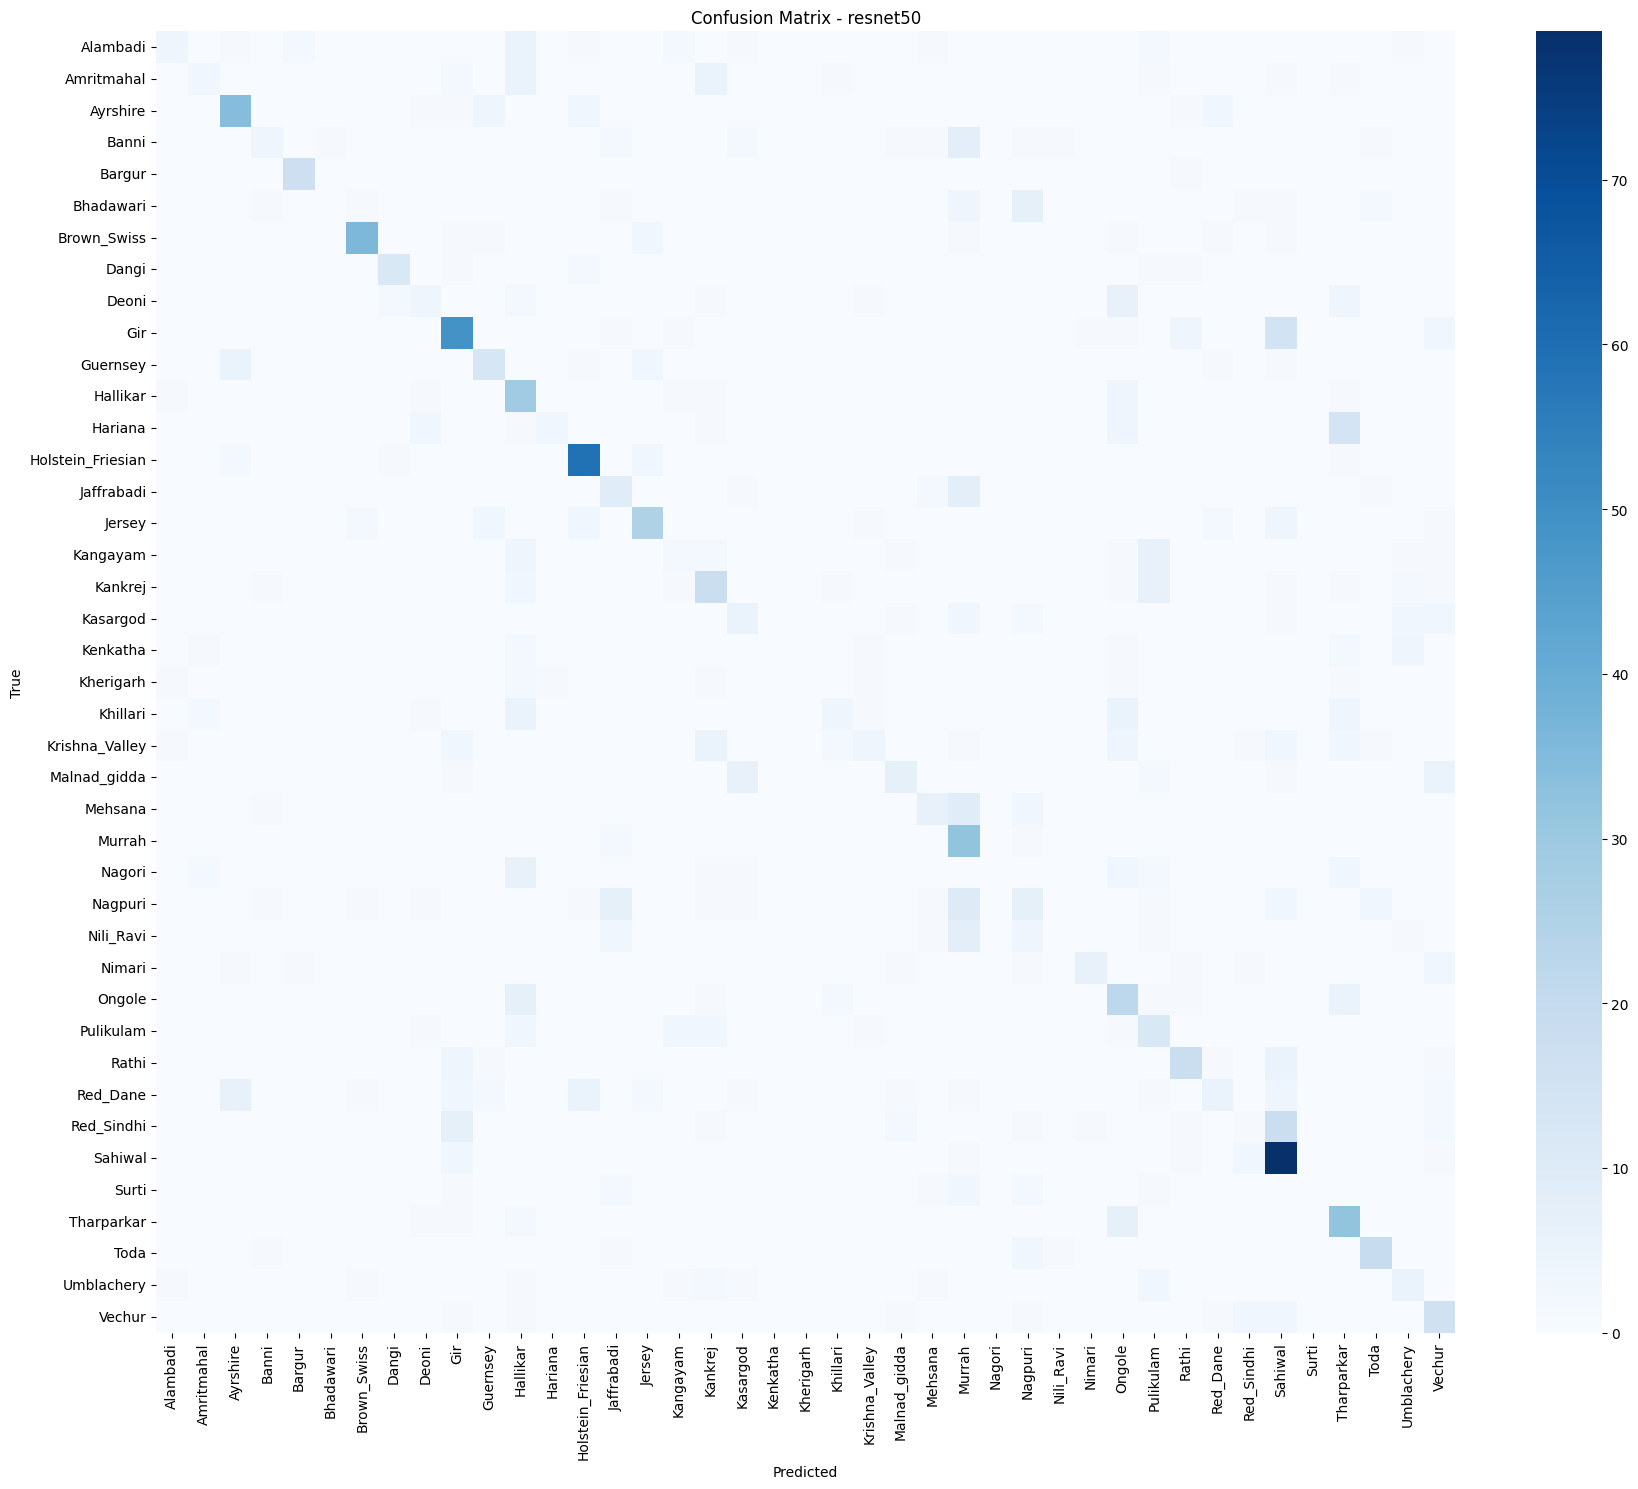

Saved resnet50 to /content/drive/MyDrive/Cattle Vision Dataset/resnet50_best.pth

Training efficientnet_b0


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

[efficientnet_b0] Epoch 1/15 | Train Loss: 3.2369 Acc: 0.1883 | Val Loss: 2.5229 Acc: 0.3288 | Time: 31.4s
[efficientnet_b0] Epoch 2/15 | Train Loss: 1.9680 Acc: 0.4609 | Val Loss: 2.0073 Acc: 0.4219 | Time: 29.3s
[efficientnet_b0] Epoch 3/15 | Train Loss: 1.3940 Acc: 0.6136 | Val Loss: 1.7723 Acc: 0.4767 | Time: 29.3s
[efficientnet_b0] Epoch 4/15 | Train Loss: 1.0465 Acc: 0.7115 | Val Loss: 1.6659 Acc: 0.5247 | Time: 29.3s
[efficientnet_b0] Epoch 5/15 | Train Loss: 0.7934 Acc: 0.7875 | Val Loss: 1.6187 Acc: 0.5452 | Time: 29.4s
[efficientnet_b0] Epoch 6/15 | Train Loss: 0.6202 Acc: 0.8440 | Val Loss: 1.6001 Acc: 0.5356 | Time: 29.6s
[efficientnet_b0] Epoch 7/15 | Train Loss: 0.4954 Acc: 0.8797 | Val Loss: 1.6095 Acc: 0.5644 | Time: 29.8s
[efficientnet_b0] Epoch 8/15 | Train Loss: 0.4034 Acc: 0.9073 | Val Loss: 1.6134 Acc: 0.5630 | Time: 30.5s
[efficientnet_b0] Epoch 9/15 | Train Loss: 0.3356 Acc: 0.9255 | Val Loss: 1.6306 Acc: 0.5548 | Time: 30.1s
[efficientnet_b0] Epoch 10/15 | Train

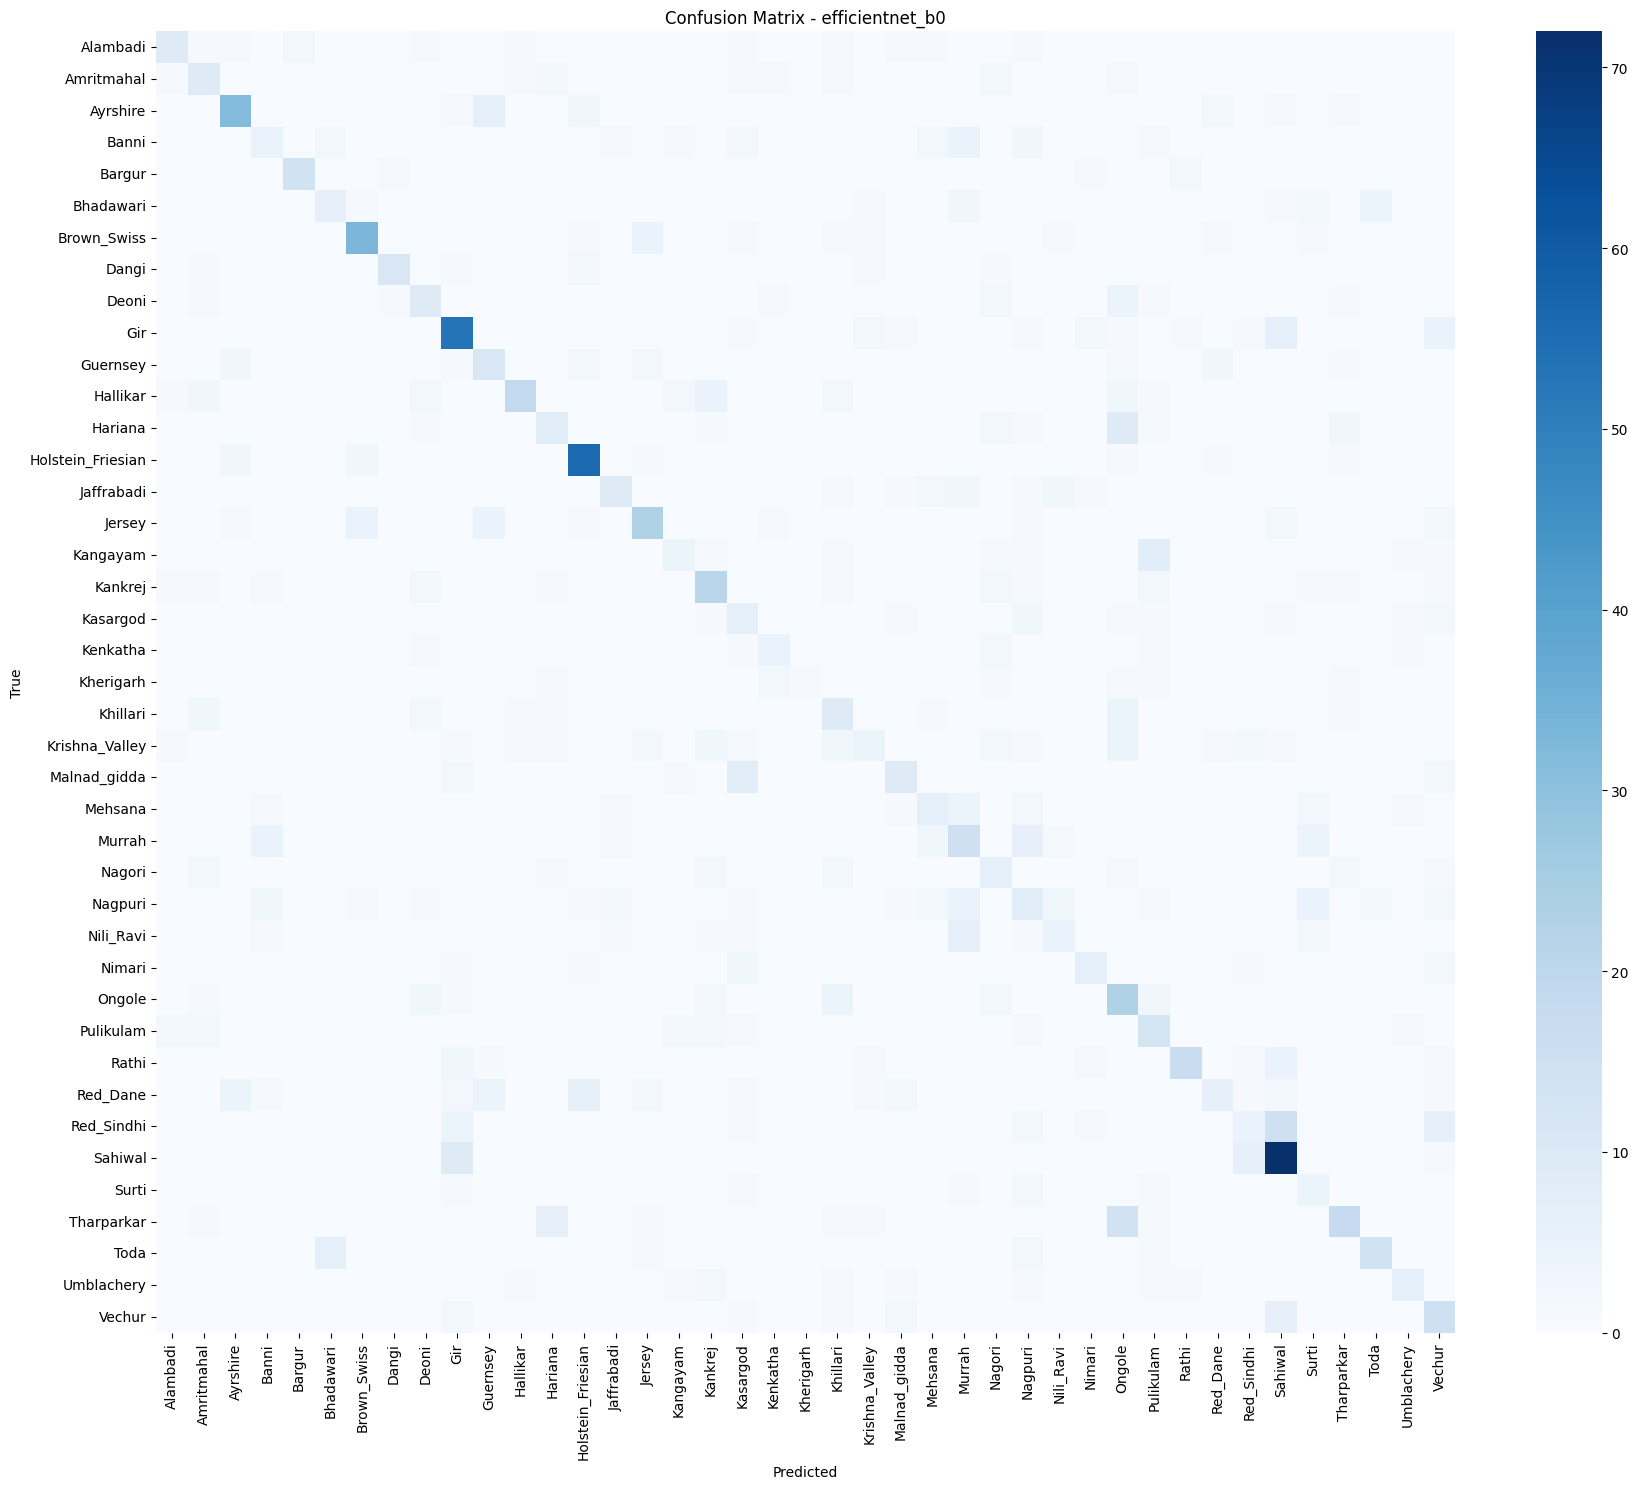

Saved efficientnet_b0 to /content/drive/MyDrive/Cattle Vision Dataset/efficientnet_b0_best.pth

Training vit


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

[vit] Epoch 1/15 | Train Loss: 2.5362 Acc: 0.3000 | Val Loss: 1.8121 Acc: 0.4548 | Time: 153.1s
[vit] Epoch 2/15 | Train Loss: 1.5519 Acc: 0.5526 | Val Loss: 1.5039 Acc: 0.5603 | Time: 151.6s
[vit] Epoch 3/15 | Train Loss: 1.0501 Acc: 0.6826 | Val Loss: 1.7282 Acc: 0.5274 | Time: 152.2s
[vit] Epoch 4/15 | Train Loss: 0.7541 Acc: 0.7583 | Val Loss: 1.7368 Acc: 0.5575 | Time: 152.0s
[vit] Epoch 5/15 | Train Loss: 0.5002 Acc: 0.8438 | Val Loss: 1.8181 Acc: 0.5466 | Time: 151.8s
[vit] Epoch 6/15 | Train Loss: 0.3542 Acc: 0.8901 | Val Loss: 1.8073 Acc: 0.5521 | Time: 152.5s
[vit] Epoch 7/15 | Train Loss: 0.2594 Acc: 0.9143 | Val Loss: 1.9372 Acc: 0.5726 | Time: 152.0s
[vit] Epoch 8/15 | Train Loss: 0.2072 Acc: 0.9312 | Val Loss: 1.9697 Acc: 0.5616 | Time: 152.0s
[vit] Epoch 9/15 | Train Loss: 0.1646 Acc: 0.9420 | Val Loss: 1.8008 Acc: 0.5986 | Time: 152.6s
[vit] Epoch 10/15 | Train Loss: 0.1274 Acc: 0.9494 | Val Loss: 1.9076 Acc: 0.5945 | Time: 151.9s
[vit] Epoch 11/15 | Train Loss: 0.1078 

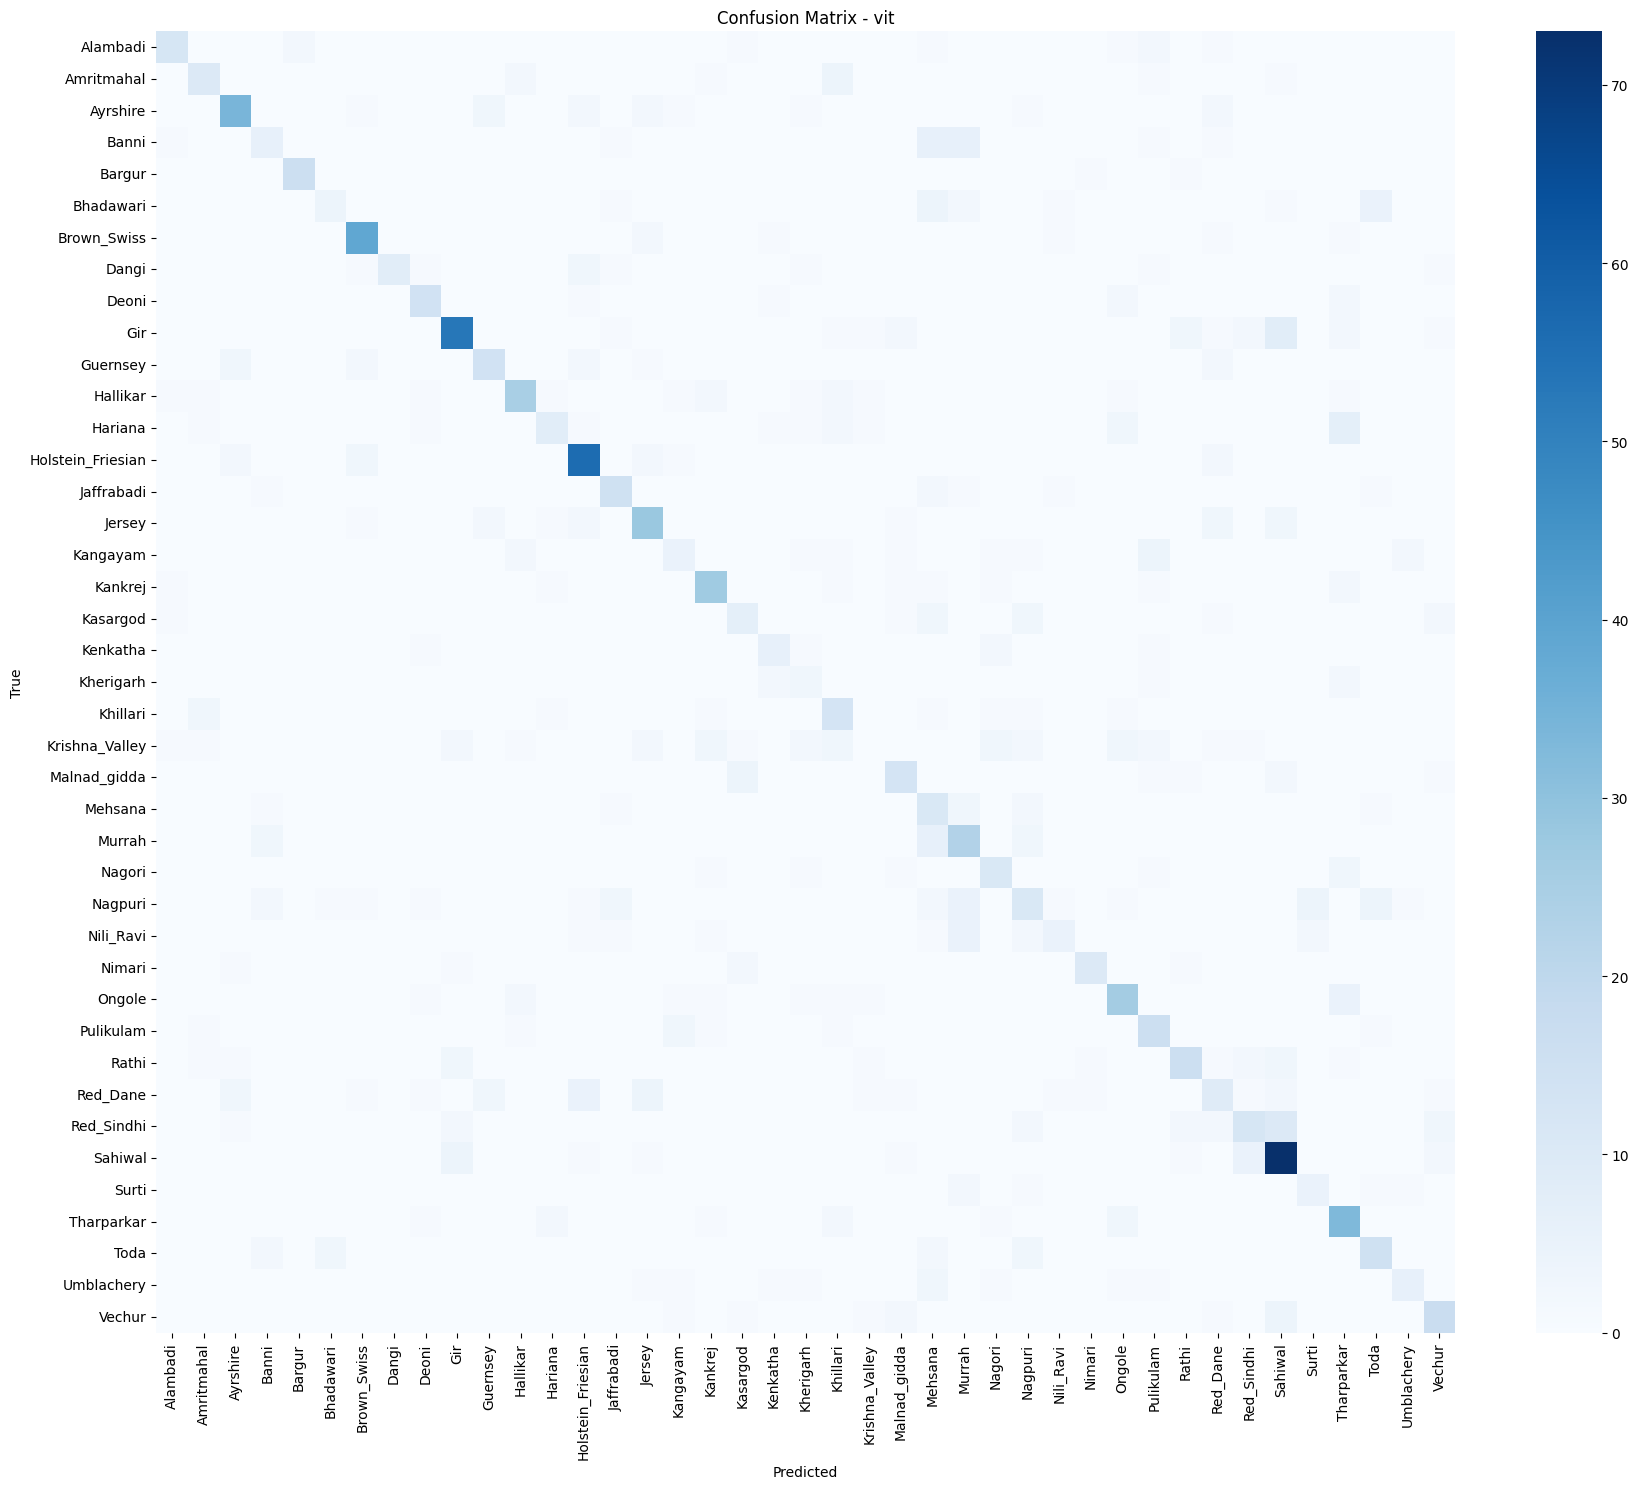

Saved vit to /content/drive/MyDrive/Cattle Vision Dataset/vit_best.pth

===== Final Comparison =====
resnet50: 0.5038
efficientnet_b0: 0.5113
vit: 0.5993


In [ ]:
results = {}
trained_models = {}

for name, timm_name in MODEL_CONFIGS.items():
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    model = build_model(timm_name, num_classes)
    model, history = train_model(model, name, train_loader, val_loader, num_epochs=15, lr=1e-4)
    test_acc = evaluate_model(model, test_loader, class_names, name)
    results[name] = test_acc
    trained_models[name] = model

    # Save checkpoint to Drive
    save_path = f"/content/drive/MyDrive/Cattle Vision Dataset/{name}_best.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Saved {name} to {save_path}")

print("\n===== Final Comparison =====")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

In [ ]:
import torch
import timm
from PIL import Image
from torchvision import transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of classes
num_classes = 41

# Create the same model architecture used for training
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=num_classes
)

# Path to your saved model
model_path = "/content/drive/MyDrive/Cattle Vision Dataset/vit_best.pth"

# Load trained weights
model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("ViT model loaded successfully!")

ViT model loaded successfully!


In [ ]:
class_names = [
    "Alambadi",
    "Amritmahal",
    "Ayrshire",
    "Banni",
    "Bargur",
    "Bhadawari",
    "Brown_Swiss",
    "Dangi",
    "Deoni",
    "Gir",
    "Guernsey",
    "Hallikar",
    "Hariana",
    "Holstein_Friesian",
    "Jaffrabadi",
    "Jersey",
    "Kangayam",
    "Kankrej",
    "Kasargod",
    "Kenkatha",
    "Kherigarh",
    "Khillari",
    "Krishna_Valley",
    "Malnad_gidda",
    "Mehsana",
    "Murrah",
    "Nagori",
    "Nagpuri",
    "Nili_Ravi",
    "Nimari",
    "Ongole",
    "Pulikulam",
    "Rathi",
    "Red_Dane",
    "Red_Sindhi",
    "Sahiwal",
    "Surti",
    "Tharparkar",
    "Toda",
    "Umblachery",
    "Vechur"
]

print("Number of classes:", len(class_names))

Number of classes: 41


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
import torch.nn.functional as F

def predict_breed(image):

    # Convert image to RGB
    image = image.convert("RGB")

    # Preprocess
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        output = model(image_tensor)

        probabilities = F.softmax(output, dim=1)

    # Get top 3 predictions
    top_probs, top_indices = torch.topk(probabilities, 3)

    top_probs = top_probs[0].cpu().numpy()
    top_indices = top_indices[0].cpu().numpy()

    # Best prediction
    predicted_index = top_indices[0]
    predicted_breed = class_names[predicted_index]
    confidence = top_probs[0] * 100

    print("=" * 50)
    print("PREDICTION RESULT")
    print("=" * 50)

    print(f"Predicted Breed : {predicted_breed}")
    print(f"Confidence      : {confidence:.2f}%")

    print("\nTop 3 Predictions:")

    for i in range(3):
        breed = class_names[top_indices[i]]
        probability = top_probs[i] * 100

        print(
            f"{i+1}. {breed} : {probability:.2f}%"
        )

    return predicted_breed, confidence

In [ ]:
!pip install -q fastapi uvicorn nest-asyncio

In [ ]:
# ============================================================
# CATTLE BREED INFORMATION API
# ============================================================

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware

breed_data = {
    "Alambadi": {
        "category": "Cattle",
        "origin": "Tamil Nadu, India",
        "main_use": "Draught work",
        "milk_production": "Approximately 1–3 litres/day; relatively low milk production.",
        "breeding_habits": "Traditionally maintained through natural breeding.",
        "climate": "Adapted to hot and dry southern Indian conditions.",
        "characteristics": "Hardy draught breed used for ploughing and cart pulling."
    },

    "Amritmahal": {
        "category": "Cattle",
        "origin": "Karnataka, India",
        "main_use": "Draught work and transport",
        "milk_production": "Low milk production; primarily a draught breed.",
        "breeding_habits": "Traditionally selected for strength, endurance and draught performance.",
        "climate": "Adapted to warm and relatively dry conditions.",
        "characteristics": "Strong, active and hardy draught breed."
    },

    "Ayrshire": {
        "category": "Cattle",
        "origin": "Scotland",
        "main_use": "Dairy",
        "milk_production": "High milk-producing dairy breed; production varies with genetics and management.",
        "breeding_habits": "Artificial insemination and natural service are commonly used.",
        "climate": "Adaptable dairy breed; good management is required under high heat.",
        "characteristics": "Efficient dairy breed known for milk quality."
    },

    "Banni": {
        "category": "Buffalo",
        "origin": "Kutch, Gujarat, India",
        "main_use": "Milk production",
        "milk_production": "Good milk-producing buffalo; yield varies according to management.",
        "breeding_habits": "Natural breeding and artificial insemination can be used.",
        "climate": "Highly adapted to hot and dry Kutch conditions.",
        "characteristics": "Hardy buffalo adapted to harsh environments."
    },

    "Bargur": {
        "category": "Cattle",
        "origin": "Tamil Nadu, India",
        "main_use": "Draught and agricultural work",
        "milk_production": "Average approximately 350 kg/lactation.",
        "breeding_habits": "Traditionally maintained under extensive management.",
        "climate": "Adapted to hilly and forest environments.",
        "characteristics": "Strong draught breed with good trotting ability."
    },

    "Bhadawari": {
        "category": "Buffalo",
        "origin": "Uttar Pradesh and Madhya Pradesh, India",
        "main_use": "Milk production",
        "milk_production": "Moderate milk production with relatively high milk fat.",
        "breeding_habits": "Natural breeding and artificial insemination may be used.",
        "climate": "Adapted to hot Indian conditions.",
        "characteristics": "Known for high-fat milk and heat adaptation."
    },

    "Brown_Swiss": {
        "category": "Cattle",
        "origin": "Switzerland",
        "main_use": "Dairy",
        "milk_production": "High milk production; yield varies with genetics and management.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Requires good heat-management practices in hot climates.",
        "characteristics": "Large dairy breed known for milk solids."
    },

    "Dangi": {
        "category": "Cattle",
        "origin": "Maharashtra and Gujarat, India",
        "main_use": "Draught and milk",
        "milk_production": "Average approximately 430 kg/lactation.",
        "breeding_habits": "Natural breeding and artificial insemination can be used.",
        "climate": "Very well adapted to heavy rainfall.",
        "characteristics": "Excellent working breed for wet, hilly and rice-growing areas."
    },

    "Deoni": {
        "category": "Cattle",
        "origin": "Maharashtra and Karnataka, India",
        "main_use": "Dairy and draught",
        "milk_production": "Approximately 868 kg/lactation on average in NDDB breed information.",
        "breeding_habits": "Natural breeding and artificial insemination are used.",
        "climate": "Adapted to semi-intensive and grazing systems.",
        "characteristics": "Dual-purpose breed with strong bullocks."
    },

    "Gir": {
        "category": "Cattle",
        "origin": "Gujarat, India",
        "main_use": "Milk production",
        "milk_production": "Approximately 2,110 kg/lactation average; selected animals may produce considerably more.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Highly adapted to hot and tropical conditions.",
        "characteristics": "Important indigenous dairy breed."
    },

    "Guernsey": {
        "category": "Cattle",
        "origin": "Guernsey, Channel Islands",
        "main_use": "Dairy",
        "milk_production": "Moderate-to-high dairy production with relatively high milk solids.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Requires shade, water and ventilation in hot climates.",
        "characteristics": "Known for rich milk."
    },

    "Hallikar": {
        "category": "Cattle",
        "origin": "Karnataka, India",
        "main_use": "Draught work",
        "milk_production": "Low milk production; primarily a draught breed.",
        "breeding_habits": "Traditionally selected for draught ability.",
        "climate": "Adapted to Karnataka climatic conditions.",
        "characteristics": "Highly valued traditional draught breed."
    },

    "Hariana": {
        "category": "Cattle",
        "origin": "Haryana, Uttar Pradesh and Rajasthan",
        "main_use": "Milk and draught",
        "milk_production": "Moderate milk production.",
        "breeding_habits": "Natural breeding and artificial insemination are used.",
        "climate": "Adapted to hot northern Indian conditions.",
        "characteristics": "Dual-purpose indigenous breed."
    },

    "Holstein_Friesian": {
        "category": "Cattle",
        "origin": "Netherlands/Germany region",
        "main_use": "Dairy",
        "milk_production": "Very high milk-producing dairy breed.",
        "breeding_habits": "Artificial insemination is widely used.",
        "climate": "Requires strong heat-stress management in tropical climates.",
        "characteristics": "One of the world's major high-yielding dairy breeds."
    },

    "Jaffrabadi": {
        "category": "Buffalo",
        "origin": "Gujarat, India",
        "main_use": "Milk production",
        "milk_production": "Good dairy buffalo with variable lactation yield.",
        "breeding_habits": "Natural breeding and artificial insemination can be used.",
        "climate": "Adapted to hot Gujarat conditions.",
        "characteristics": "Large buffalo known for dairy ability."
    },

    "Jersey": {
        "category": "Cattle",
        "origin": "Jersey, Channel Islands",
        "main_use": "Dairy",
        "milk_production": "Good milk production with relatively high milk-fat content.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Better heat tolerance than some larger dairy breeds but still requires heat management.",
        "characteristics": "Small-to-medium dairy breed with high-fat milk."
    },

    "Kangayam": {
        "category": "Cattle",
        "origin": "Tamil Nadu, India",
        "main_use": "Draught work",
        "milk_production": "Low milk production.",
        "breeding_habits": "Traditionally selected for draught performance.",
        "climate": "Adapted to hot and dry conditions.",
        "characteristics": "Strong and hardy draught breed."
    },

    "Kankrej": {
        "category": "Cattle",
        "origin": "Gujarat and Rajasthan",
        "main_use": "Milk and draught",
        "milk_production": "Moderate milk production.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Adapted to hot and dry environments.",
        "characteristics": "Dual-purpose breed with strong draught ability."
    },

    "Kasargod": {
        "category": "Cattle",
        "origin": "Kerala, India",
        "main_use": "Milk and local farming",
        "milk_production": "Low-to-moderate milk production.",
        "breeding_habits": "Traditionally maintained through local breeding.",
        "climate": "Adapted to humid Kerala conditions.",
        "characteristics": "Local hardy cattle adapted to low-input systems."
    },

    "Kenkatha": {
        "category": "Cattle",
        "origin": "Uttar Pradesh and Madhya Pradesh",
        "main_use": "Draught",
        "milk_production": "Low milk production.",
        "breeding_habits": "Traditionally selected for draught ability.",
        "climate": "Adapted to central and northern Indian conditions.",
        "characteristics": "Hardy indigenous draught breed."
    },

    "Kherigarh": {
        "category": "Cattle",
        "origin": "Uttar Pradesh",
        "main_use": "Draught",
        "milk_production": "Low milk production.",
        "breeding_habits": "Traditionally selected for working ability.",
        "climate": "Adapted to northern Indian conditions.",
        "characteristics": "Hardy draught cattle."
    },

    "Khillari": {
        "category": "Cattle",
        "origin": "Maharashtra and Karnataka",
        "main_use": "Draught",
        "milk_production": "Low milk production; primarily a draught breed.",
        "breeding_habits": "Traditionally selected for strength and endurance.",
        "climate": "Adapted to tropical, dry and drought-prone conditions.",
        "characteristics": "Strong and hardy agricultural breed."
    },

    "Krishna_Valley": {
        "category": "Cattle",
        "origin": "Karnataka",
        "main_use": "Draught and dual purpose",
        "milk_production": "Low-to-moderate milk production.",
        "breeding_habits": "Natural breeding and artificial insemination may be used.",
        "climate": "Adapted to warm and dry conditions.",
        "characteristics": "Large indigenous breed useful for agricultural work."
    },

    "Malnad_gidda": {
        "category": "Cattle",
        "origin": "Karnataka",
        "main_use": "Milk and low-input farming",
        "milk_production": "Low milk production; approximately 542 kg/lactation in one Karnataka breeding-policy dataset.",
        "breeding_habits": "Traditionally maintained in local low-input systems.",
        "climate": "Adapted to humid and hilly Malnad conditions.",
        "characteristics": "Small, hardy cattle well suited to low-input systems."
    },

    "Mehsana": {
        "category": "Buffalo",
        "origin": "Gujarat, India",
        "main_use": "Milk production",
        "milk_production": "Average first-lactation yield around 1,972 kg in an NDDB study.",
        "breeding_habits": "Systematic genetic improvement and artificial insemination are used.",
        "climate": "Adapted to hot Gujarat conditions.",
        "characteristics": "Dairy buffalo developed from Murrah and Surti background."
    },

    "Murrah": {
        "category": "Buffalo",
        "origin": "Haryana and Punjab region",
        "main_use": "Milk production",
        "milk_production": "High milk-producing buffalo; yield varies by herd and management.",
        "breeding_habits": "Natural service and artificial insemination are widely used.",
        "climate": "Requires shade, water and heat-stress management in hot conditions.",
        "characteristics": "One of India's most important dairy buffalo breeds."
    },

    "Nagori": {
        "category": "Cattle",
        "origin": "Rajasthan",
        "main_use": "Draught",
        "milk_production": "Low milk production.",
        "breeding_habits": "Traditionally selected for working ability.",
        "climate": "Highly adapted to dry Rajasthan conditions.",
        "characteristics": "Hardy draught breed."
    },

    "Nagpuri": {
        "category": "Buffalo",
        "origin": "Maharashtra, India",
        "main_use": "Milk and agricultural use",
        "milk_production": "Moderate milk production.",
        "breeding_habits": "Natural breeding and artificial insemination may be used.",
        "climate": "Adapted to hot and dry conditions.",
        "characteristics": "Hardy indigenous buffalo."
    },

    "Nili_Ravi": {
        "category": "Buffalo",
        "origin": "Punjab region",
        "main_use": "Milk production",
        "milk_production": "Good dairy buffalo with high milk potential.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Adapted to northern Indian/Punjab conditions; heat management is important.",
        "characteristics": "Important dairy buffalo breed."
    },

    "Nimari": {
        "category": "Cattle",
        "origin": "Madhya Pradesh",
        "main_use": "Draught and milk",
        "milk_production": "Low-to-moderate milk production.",
        "breeding_habits": "Natural breeding and artificial insemination can be used.",
        "climate": "Adapted to central Indian conditions.",
        "characteristics": "Hardy dual-purpose indigenous cattle."
    },

    "Ongole": {
        "category": "Cattle",
        "origin": "Andhra Pradesh",
        "main_use": "Draught and traditional cattle production",
        "milk_production": "Low-to-moderate milk production.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Adapted to hot and dry tropical conditions.",
        "characteristics": "Large, powerful and hardy indigenous cattle."
    },

    "Pulikulam": {
        "category": "Cattle",
        "origin": "Tamil Nadu",
        "main_use": "Draught and traditional livestock systems",
        "milk_production": "Low milk production.",
        "breeding_habits": "Traditionally maintained through natural breeding.",
        "climate": "Adapted to hot and dry southern Indian conditions.",
        "characteristics": "Hardy cattle associated with traditional pastoral systems."
    },

    "Rathi": {
        "category": "Cattle",
        "origin": "Rajasthan",
        "main_use": "Milk and dual purpose",
        "milk_production": "Average approximately 1,560 kg/lactation in NDDB breed information.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Well adapted to hot and dry Rajasthan conditions.",
        "characteristics": "Important dairy breed of arid Rajasthan."
    },

    "Red_Dane": {
        "category": "Cattle",
        "origin": "Denmark",
        "main_use": "Dairy",
        "milk_production": "High milk-producing dairy breed.",
        "breeding_habits": "Artificial insemination and natural service are used.",
        "climate": "Requires heat management in tropical climates.",
        "characteristics": "European dairy breed."
    },

    "Red_Sindhi": {
        "category": "Cattle",
        "origin": "Sindh region",
        "main_use": "Milk production",
        "milk_production": "Moderate-to-good milk production.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Well adapted to hot tropical conditions.",
        "characteristics": "Important heat-tolerant indigenous dairy breed."
    },

    "Sahiwal": {
        "category": "Cattle",
        "origin": "Punjab and Rajasthan region",
        "main_use": "Milk production",
        "milk_production": "Average approximately 2,325 kg/lactation in NDDB breed information.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Well adapted to hot tropical conditions.",
        "characteristics": "One of India's important indigenous dairy breeds."
    },

    "Surti": {
        "category": "Buffalo",
        "origin": "Gujarat",
        "main_use": "Milk production",
        "milk_production": "Moderate dairy production with good milk-fat content.",
        "breeding_habits": "Natural breeding and artificial insemination are used.",
        "climate": "Adapted to Gujarat conditions.",
        "characteristics": "Important indigenous dairy buffalo."
    },

    "Tharparkar": {
        "category": "Cattle",
        "origin": "Rajasthan",
        "main_use": "Milk and draught",
        "milk_production": "Moderate milk production.",
        "breeding_habits": "Natural service and artificial insemination are used.",
        "climate": "Highly adapted to hot and dry conditions.",
        "characteristics": "Hardy dual-purpose desert-region breed."
    },

    "Toda": {
        "category": "Buffalo",
        "origin": "Nilgiri Hills, Tamil Nadu",
        "main_use": "Milk and traditional pastoral system",
        "milk_production": "Low-to-moderate milk production.",
        "breeding_habits": "Traditionally maintained within pastoral herds.",
        "climate": "Adapted to the cool, hilly Nilgiri environment.",
        "characteristics": "Distinctive indigenous buffalo breed associated with the Toda pastoral community."
    },

    "Umblachery": {
        "category": "Cattle",
        "origin": "Tamil Nadu",
        "main_use": "Draught and agriculture",
        "milk_production": "Low milk production.",
        "breeding_habits": "Natural breeding is traditionally used.",
        "climate": "Adapted to hot and humid Tamil Nadu conditions.",
        "characteristics": "Hardy draught cattle suited to agricultural work."
    },

    "Vechur": {
        "category": "Cattle",
        "origin": "Kerala",
        "main_use": "Milk and low-input farming",
        "milk_production": "Low-volume milk producer; known for relatively high milk-fat content.",
        "breeding_habits": "Traditionally maintained through natural breeding.",
        "climate": "Well adapted to Kerala's humid tropical conditions.",
        "characteristics": "Very small indigenous cattle breed with excellent adaptability."
    }
}


# Create FastAPI application
app = FastAPI(
    title="Cattle Breed Information API",
    description="API for the Cattle Breed Identification project",
    version="1.0"
)

# Allow GUI to communicate with API
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"]
)


@app.get("/")
def home():
    return {
        "message": "Cattle Breed Information API is running"
    }


@app.get("/breed/{breed_name}")
def get_breed_information(breed_name: str):

    # Case-insensitive matching
    selected_breed = None

    for breed in breed_data:

        if breed.lower() == breed_name.lower():
            selected_breed = breed
            break

    # Breed not available
    if selected_breed is None:

        return {
            "status": "not_found",
            "message": f"Information for {breed_name} is not available yet."
        }

    # Breed found
    return {
        "status": "success",
        "breed": selected_breed,
        **breed_data[selected_breed]
    }


print("✅ Breed information database created")
print("✅ FastAPI application created")
print("Available breeds:")
print(list(breed_data.keys()))

✅ Breed information database created
✅ FastAPI application created
Available breeds:
['Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadawari', 'Brown_Swiss', 'Dangi', 'Deoni', 'Gir', 'Guernsey', 'Hallikar', 'Hariana', 'Holstein_Friesian', 'Jaffrabadi', 'Jersey', 'Kangayam', 'Kankrej', 'Kasargod', 'Kenkatha', 'Kherigarh', 'Khillari', 'Krishna_Valley', 'Malnad_gidda', 'Mehsana', 'Murrah', 'Nagori', 'Nagpuri', 'Nili_Ravi', 'Nimari', 'Ongole', 'Pulikulam', 'Rathi', 'Red_Dane', 'Red_Sindhi', 'Sahiwal', 'Surti', 'Tharparkar', 'Toda', 'Umblachery', 'Vechur']


In [ ]:

# FASTAPI SERVER


import nest_asyncio
import uvicorn
import threading

nest_asyncio.apply()


def run_api():

    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )


api_thread = threading.Thread(
    target=run_api,
    daemon=True
)

api_thread.start()

print("✅ Cattle Breed API started on port 8000")

✅ Cattle Breed API started on port 8000


INFO:     Started server process [2754]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [ ]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/breed/Gir"
)

print("Status code:", response.status_code)
print("Response:")
print(response.json())

INFO:     127.0.0.1:34456 - "GET /breed/Gir HTTP/1.1" 200 OK
Status code: 200
Response:
{'status': 'success', 'breed': 'Gir', 'category': 'Cattle', 'origin': 'Gujarat, India', 'main_use': 'Milk production', 'milk_production': 'Approximately 2,110 kg/lactation average; selected animals may produce considerably more.', 'breeding_habits': 'Natural service and artificial insemination are used.', 'climate': 'Highly adapted to hot and tropical conditions.', 'characteristics': 'Important indigenous dairy breed.'}


In [ ]:

import torch
import torch.nn.functional as F
import requests


def predict_breed_gui(image):

    if image is None:

        return (
            "Please upload a cattle image.",
            "",
            "No image uploaded.",
            ""
        )

    image = image.convert("RGB")

    image_tensor = transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = F.softmax(
            output,
            dim=1
        )

    top_probs, top_indices = torch.topk(
        probabilities,
        3
    )


    top_probs = top_probs[0].cpu().numpy()
    top_indices = top_indices[0].cpu().numpy()

    predicted_breed = class_names[
        top_indices[0]
    ]

    confidence = (
        top_probs[0] * 100
    )

    prediction_text = (
        f"🐄 Predicted Breed: {predicted_breed}\n\n"
        f"🎯 Confidence: {confidence:.2f}%"
    )


    top3_text = ""

    for i in range(3):

        breed = class_names[
            top_indices[i]
        ]

        probability = (
            top_probs[i] * 100
        )

        top3_text += (
            f"{i+1}. {breed} — "
            f"{probability:.2f}%\n"
        )



    try:

        api_url = (
            "http://127.0.0.1:8000/breed/"
            + predicted_breed
        )

        api_response = requests.get(
            api_url,
            timeout=5
        )

        breed_info = api_response.json()


    except Exception as error:

        breed_info = {
            "status": "error",
            "message": str(error)
        }

    if breed_info.get("status") == "success":

        information_text = (

            f"🐄 Breed: "
            f"{breed_info.get('breed', 'N/A')}\n\n"

            f"📂 Category: "
            f"{breed_info.get('category', 'N/A')}\n\n"

            f"📍 Origin:\n"
            f"{breed_info.get('origin', 'N/A')}\n\n"

            f"🎯 Main Use:\n"
            f"{breed_info.get('main_use', 'N/A')}\n\n"

            f"🥛 Milk Production:\n"
            f"{breed_info.get('milk_production', 'N/A')}\n\n"

            f"🧬 Breeding:\n"
            f"{breed_info.get('breeding_habits', 'N/A')}\n\n"

            f"🌡️ Climate:\n"
            f"{breed_info.get('climate', 'N/A')}\n\n"

            f"⭐ Characteristics:\n"
            f"{breed_info.get('characteristics', 'N/A')}"
        )

    else:

        information_text = (
            f"Information for {predicted_breed} "
            f"is not available in the API yet."
        )


    return (
        prediction_text,
        top3_text,
        information_text,
        predicted_breed
    )

In [ ]:

import gradio as gr
with gr.Blocks(
    title="Cattle Vision - Breed Identification"
) as demo:



    gr.Markdown(
        """
        # 🐄 Cattle Vision
        ## Cattle Breed Identification System

        Upload a cattle image to identify its breed
        and retrieve breed information.
        """
    )



    with gr.Row():

        # LEFT
        with gr.Column():

            image_input = gr.Image(
                type="pil",
                label="📷 Upload Cattle Image"
            )

            predict_button = gr.Button(
                "🔍 Predict Breed",
                variant="primary"
            )


        # RIGHT
        with gr.Column():

            prediction_output = gr.Textbox(
                label="🐄 Prediction",
                lines=4
            )

            top3_output = gr.Textbox(
                label="🏆 Top 3 Predictions",
                lines=5
            )

    gr.Markdown(
        """
        ## Breed Information
        """
    )


    information_output = gr.Textbox(
        label="Breed Information",
        lines=16
    )


    # Hidden output
    predicted_breed_output = gr.Textbox(
        visible=False
    )


    predict_button.click(

        fn=predict_breed_gui,

        inputs=image_input,

        outputs=[
            prediction_output,
            top3_output,
            information_output,
            predicted_breed_output
        ]
    )


demo.launch(
    share=True,
    inbrowser=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fa80e407eb271ee384.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
